In [1]:
 # Required packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import scipy.sparse as sp


## Data loading
##### TR1, L2, TR2 (Europarl) and NN (non-native Europarl)

In [3]:
# this has both L2 and TR from previous experiments

df = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/Implementation/TR1%20and%20L2/L2_TR.csv")

df = df.drop(columns=["Unnamed: 0","sentlength","alang","akorp","afile"],axis = "columns")
df = df.rename(columns={"astatus": "dataset_name"})

num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)

# Count of L1 per L2
count_per_L2 = df.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0)

print(count_per_L2)

# Data balancing across entire data set
L2 = df[df['dataset_name'] == 'L2']
TR1 = df[df['dataset_name'] == 'TR']


""" concating lets do it afterwards!
df_balanced_1100 = pd.concat([df_L2, df_TR_downsampled_1100], ignore_index=True)"""


# Europarl data

TR2 = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/Data%20Generation/Datasets/europarl/europarl_all_data.csv")

TR2 = TR2.drop(columns="sentlength",axis = "columns")
TR2 = TR2.drop(columns=["Unnamed: 0","alang","akorp","afile","astatus"],axis = "columns")


num_cols = TR2.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)



# Non-native Europarl (NN): merged feature file with the L1 column (fr, it, es, de)
# Colab: upload NN_all_out.csv in the Files panel on the left, or put its raw GitHub URL here
NN_PATH = "NN_all_out.csv"

def read_features(path):
    """Read a feature file whether it is tab-, ';'- or ','-separated."""
    for sep in ["\t", ";", ","]:
        d = pd.read_csv(path, sep=sep)
        if d.shape[1] > 1:
            return d
    return d

NN = read_features(NN_PATH)
NN = NN.drop(columns=["Unnamed: 0", "sentlength", "alang", "akorp", "afile", "astatus"], errors="ignore")

# NN must have the same feature columns as the other data sets
missing = [c for c in numerical_cols if c not in NN.columns]
extra = [c for c in NN.columns if c not in numerical_cols + ["L1"]]
print("NN rows:", len(NN), "| missing feature columns:", missing, "| extra columns:", extra)
print(NN["L1"].value_counts())


Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']
L1               de     es     fr    it
dataset_name                           
L2             1100   1100   1100  1100
TR            27743  18604  89626  2167
Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs',

# RQ1: How well can we recognize the L1 of a text using supervised ML?

In [4]:
import scipy.sparse as sp
from sklearn.metrics import confusion_matrix


def run_nn(df, features, label_col="L1", title="Neural Network"):


    X = df[features].values
    y = df[label_col].values

    if y.dtype.kind in {'O', 'U', 'S'}:  # string/object
        le = LabelEncoder()
        y = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"Length: {len(df)}, Train: {len(X_train)}, Test: {len(X_test)}")

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Ensure X is dense float64

    def to_dense_float(a):
        if sp.issparse(a):
            a = a.toarray()
        return np.asarray(a, dtype=np.float64)

    X_train_s = to_dense_float(X_train_s)
    X_test_s  = to_dense_float(X_test_s)


    # Ensure y is a plain 1D array (not sparse, not weird dtype)
    y_train = np.asarray(y_train)
    y_test  = np.asarray(y_test)


    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    mlp.fit(X_train_s, y_train)

    y_pred = mlp.predict(X_test_s)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n===== {title} =====")
    print("Test Accuracy:", accuracy)

    cm = confusion_matrix(y_test, y_pred)

    label_map = {0: "de", 1: "es", 2: "fr", 3: "it"}

    labels = sorted(label_map.keys())
    target_names = [label_map[i] for i in labels]

    print(
        "\nClassification Report:\n",
        classification_report(
            y_test,
            y_pred,
            labels=labels,
            target_names=target_names,
            digits=4
        )
    )

    # The LabelEncoder may re-order classes, so use le.classes_
    # and convert them back to original coded labels
    classes = le.classes_                    # e.g. ["de","es","fr","it"]
    classes_int = le.transform(classes)      # e.g. [0,1,2,3]
    classes_str = [label_map[i] for i in classes_int]

    print("\nConfusion matrix:")
    print(cm)

    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=classes_str,
        yticklabels=classes_str
    )
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


    return mlp, accuracy, cm


In [5]:
min_count = L2["L1"].value_counts().min()

# Downsample each class L2 to that size
L2 = (
    L2
    .groupby('L1', group_keys=False)
    .sample(n=min_count, random_state=42)
)

#----------------------------------------------
min_count = TR1["L1"].value_counts().min()

# Downsample each class to that size
TR1 = (
    TR1
    .groupby('L1', group_keys=False)
    .sample(n=min_count, random_state=42)
)
TR1 = TR1.dropna()



#------------------------------------------------
min_count = TR2["L1"].value_counts().min()

# Downsample each class to that size
TR2 = (
    TR2
    .groupby('L1', group_keys=False)
    .sample(n=min_count, random_state=42)
)


#------------------------------------------------
NN = NN.dropna()
min_count = NN["L1"].value_counts().min()

# Downsample each class to that size
NN = (
    NN
    .groupby('L1', group_keys=False)
    .sample(n=min_count, random_state=42)
)


#-------------------------------------------------
TR1.loc[:, "dataset_name"] = "TR1"
TR2.loc[:, "dataset_name"] = "TR2"
L2.loc[:, "dataset_name"] = "L2"
NN.loc[:, "dataset_name"] = "NN"


df = pd.concat([TR1, L2, TR2, NN], axis=0, ignore_index=True)
print(df.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0))

L1              de    es    fr    it
dataset_name                        
L2            1100  1100  1100  1100
NN              31    31    31    31
TR1           2153  2167  2167  2159
TR2            272   272   272   272


Length: 14258, Train: 11406, Test: 2852

===== MLP Classification of all dataset(Test set) =====
Test Accuracy: 0.5795932678821879

Classification Report:
               precision    recall  f1-score   support

          de     0.5797    0.5373    0.5577       711
          es     0.5515    0.5924    0.5712       714
          fr     0.5801    0.5784    0.5792       714
          it     0.6092    0.6101    0.6097       713

    accuracy                         0.5796      2852
   macro avg     0.5801    0.5796    0.5795      2852
weighted avg     0.5801    0.5796    0.5795      2852


Confusion matrix:
[[382  94 102 133]
 [ 67 423 131  93]
 [121 127 413  53]
 [ 89 123  66 435]]


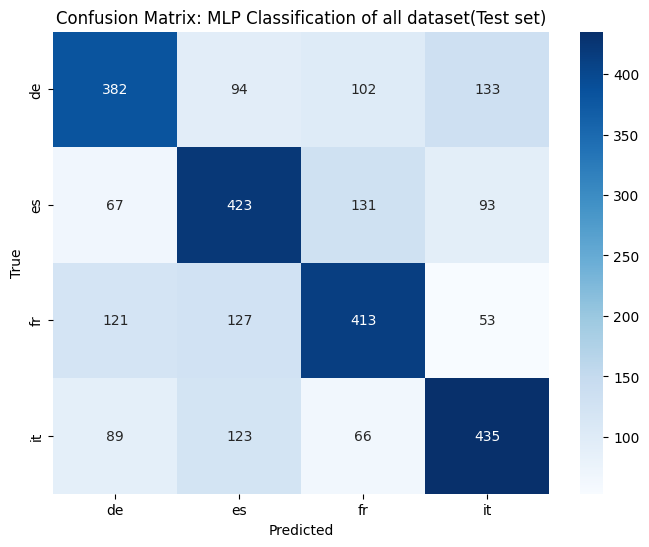

In [6]:
features = df.drop(columns=['L1',"dataset_name"]).select_dtypes(include=[np.number]).columns
#df = df.dropna()
mlp_model, acc, cm = run_nn(df, features, label_col="L1", title="MLP Classification of all dataset(Test set)")

#RQ2: Which language production type shows stronger shining-through?

Length: 4400, Train: 3520, Test: 880

===== MLP Classification of L2 dataset(Test set) =====
Test Accuracy: 0.48295454545454547

Classification Report:
               precision    recall  f1-score   support

          de     0.4801    0.6045    0.5352       220
          es     0.4749    0.4727    0.4738       220
          fr     0.4673    0.4227    0.4439       220
          it     0.5135    0.4318    0.4691       220

    accuracy                         0.4830       880
   macro avg     0.4840    0.4830    0.4805       880
weighted avg     0.4840    0.4830    0.4805       880


Confusion matrix:
[[133  30  35  22]
 [ 41 104  40  35]
 [ 59  35  93  33]
 [ 44  50  31  95]]


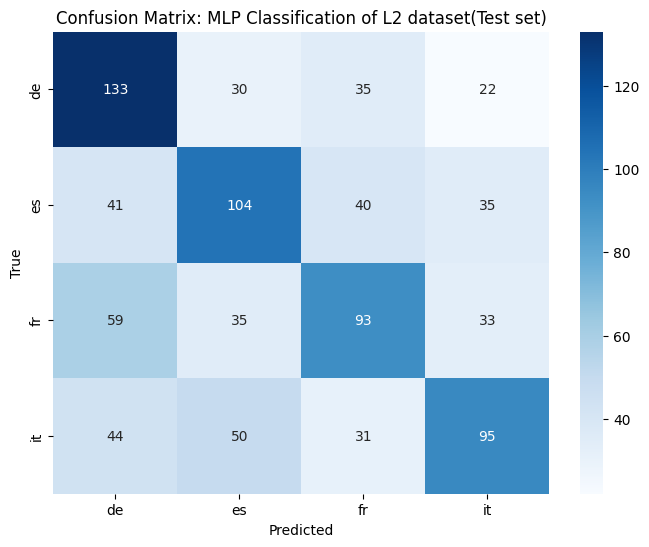

In [7]:
features = L2.drop(columns=['L1',"dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(L2, features, label_col="L1", title="MLP Classification of L2 dataset(Test set)")

Length: 8646, Train: 6916, Test: 1730

===== MLP Classification of TR1 dataset(Test set) =====
Test Accuracy: 0.6092485549132948

Classification Report:
               precision    recall  f1-score   support

          de     0.5854    0.4292    0.4953       431
          es     0.5812    0.6843    0.6286       434
          fr     0.6859    0.6305    0.6570       433
          it     0.5921    0.6921    0.6382       432

    accuracy                         0.6092      1730
   macro avg     0.6112    0.6090    0.6048      1730
weighted avg     0.6112    0.6092    0.6049      1730


Confusion matrix:
[[185  74  41 131]
 [ 37 297  60  40]
 [ 41  84 273  35]
 [ 53  56  24 299]]


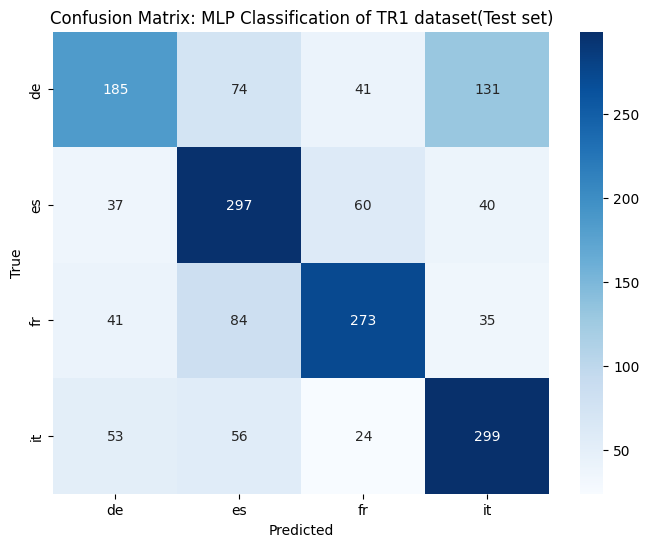

In [8]:
features = TR1.drop(columns=['L1',"dataset_name"]).select_dtypes(include=[np.number]).columns
TR1 = TR1.dropna()
mlp_model, acc, cm = run_nn(TR1, features, label_col="L1", title="MLP Classification of TR1 dataset(Test set)")

Length: 1088, Train: 870, Test: 218

===== MLP Classification of TR2 dataset(Test set) =====
Test Accuracy: 0.7614678899082569

Classification Report:
               precision    recall  f1-score   support

          de     0.8226    0.9273    0.8718        55
          es     0.6275    0.5926    0.6095        54
          fr     0.8235    0.7636    0.7925        55
          it     0.7593    0.7593    0.7593        54

    accuracy                         0.7615       218
   macro avg     0.7582    0.7607    0.7583       218
weighted avg     0.7588    0.7615    0.7589       218


Confusion matrix:
[[51  1  3  0]
 [ 5 32  6 11]
 [ 3  8 42  2]
 [ 3 10  0 41]]


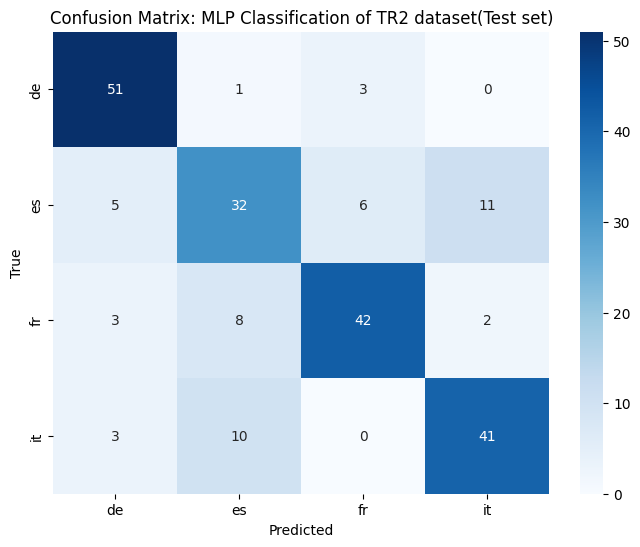

In [9]:
features = TR2.drop(columns=['L1']).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(TR2, features, label_col="L1", title="MLP Classification of TR2 dataset(Test set)")

Length: 124, Train: 99, Test: 25

===== MLP Classification of NN dataset(Test set) =====
Test Accuracy: 0.2

Classification Report:
               precision    recall  f1-score   support

          de     0.2273    0.8333    0.3571         6
          es     0.0000    0.0000    0.0000         6
          fr     0.0000    0.0000    0.0000         7
          it     0.0000    0.0000    0.0000         6

    accuracy                         0.2000        25
   macro avg     0.0568    0.2083    0.0893        25
weighted avg     0.0545    0.2000    0.0857        25


Confusion matrix:
[[5 0 1 0]
 [5 0 0 1]
 [7 0 0 0]
 [5 0 1 0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


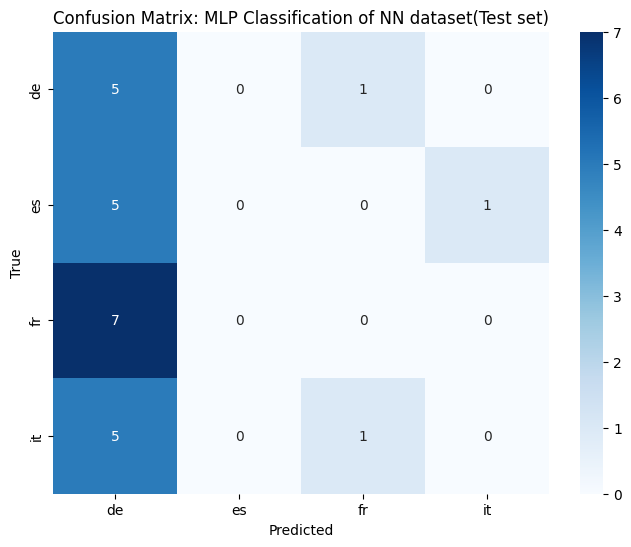

In [10]:
features = NN.drop(columns=['L1',"dataset_name"]).select_dtypes(include=[np.number]).columns
mlp_model, acc, cm = run_nn(NN, features, label_col="L1", title="MLP Classification of NN dataset(Test set)")

# RQ3: Train on one and test on others - NN
- (L2 -> TR1)
- (L2 ->TR2)
- (TR1 ->TR2)
- (TR1 ->L2)
- (TR2 ->L2)
- (TR2 ->TR1)
- (NN -> L2)
- (NN -> TR1)
- (NN -> TR2)
- (L2 -> NN)
- (TR1 -> NN)
- (TR2 -> NN)

In [11]:
exclude_cols = ["L1", "dataset_name", "L1_num"]

features = [col for col in L2.columns if col not in exclude_cols]

In [12]:
# smallest sample in Europarl is of 272 (Es) hence downsampling every data
TR1 = (
    TR1
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

L2 = (
    L2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)


TR2 = (
    TR2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)
# NN: 272 per L1 as well if it has that many, otherwise all it has (balanced)
n_nn = min(272, NN["L1"].value_counts().min())
if n_nn < 272:
    print(f"NN has only {n_nn} texts per L1 -> NN uses {n_nn} per L1, the other data sets 272")
NN = (
    NN
    .groupby('L1', group_keys=False)
    .sample(n=n_nn, random_state=42)
)

TR1["dataset_name"] = "TR1"
TR2["dataset_name"] = "TR2"
L2["dataset_name"] = "L2"
NN["dataset_name"] = "NN"


df = pd.concat([TR1, L2, TR2, NN], axis=0, ignore_index=True)

NN has only 31 texts per L1 -> NN uses 31 per L1, the other data sets 272


In [13]:
def train_one_test_one(
    train_df,
    test_df,
    features,
    label_col="L1",
    title="Cross Dataset NN",
    plot=True
):

    # -----------------------
    # 1. Split features/labels
    # -----------------------
    X_train = train_df[features].values
    y_train = train_df[label_col].values

    X_test = test_df[features].values
    y_test = test_df[label_col].values

    # -----------------------
    # 2. Label Encoding (fit ONLY on train)
    # -----------------------
    if y_train.dtype.kind in {'O', 'U', 'S'}:
        le = LabelEncoder()
        y_train = le.fit_transform(y_train)
        y_test = le.transform(y_test)
    else:
        le = None

    # -----------------------
    # 3. Handle NaNs (IMPORTANT)
    # -----------------------
    imputer = SimpleImputer(strategy="mean")
    X_train = imputer.fit_transform(X_train)
    X_test  = imputer.transform(X_test)

    # -----------------------
    # 4. Scaling (fit ONLY on train)
    # -----------------------
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # -----------------------
    # 5. Ensure dense float
    # -----------------------
    def to_dense_float(a):
        if sp.issparse(a):
            a = a.toarray()
        return np.asarray(a, dtype=np.float64)

    X_train = to_dense_float(X_train)
    X_test  = to_dense_float(X_test)

    y_train = np.asarray(y_train)
    y_test  = np.asarray(y_test)

    # -----------------------
    # 6. Model
    # -----------------------
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )


    mlp.fit(X_train, y_train)

    # -----------------------
    # 7. Prediction
    # -----------------------
    y_pred = mlp.predict(X_test)

    # -----------------------
    # 8. Metrics
    # -----------------------
    accuracy = accuracy_score(y_test, y_pred)

    print(f"\n===== {title} =====")
    print("Test Accuracy:", accuracy)

    print("\nClassification Report:\n",
          classification_report(y_test, y_pred, digits=4, zero_division=0))

    # -----------------------
    # 9. Confusion Matrix (clean + aligned)
    # -----------------------
    labels = sorted(set(y_test) | set(y_pred))

    cm_df = pd.crosstab(
        y_test,
        y_pred,
        rownames=['True'],
        colnames=['Pred']
    ).reindex(index=labels, columns=labels, fill_value=0)

    # Optional: map labels to readable names
    if le is not None:
        class_names = le.inverse_transform(labels)
        cm_df.index = class_names
        cm_df.columns = class_names

    print("\nConfusion Matrix:\n", cm_df)

    # -----------------------
    # 10. Plot
    # -----------------------
    if plot:
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm_df,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=cm_df.columns,
            yticklabels=cm_df.index
        )
        plt.title(f"Confusion Matrix: {title}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    return mlp, accuracy, cm_df


===== TR1 -> L2 =====
Test Accuracy: 0.24540441176470587

Classification Report:
               precision    recall  f1-score   support

           0     0.3214    0.0662    0.1098       272
           1     0.2378    0.4301    0.3063       272
           2     0.4082    0.0735    0.1246       272
           3     0.2281    0.4118    0.2936       272

    accuracy                         0.2454      1088
   macro avg     0.2989    0.2454    0.2086      1088
weighted avg     0.2989    0.2454    0.2086      1088


Confusion Matrix:
     de   es  fr   it
de  18  125   6  123
es  11  117  10  134
fr  18  112  20  122
it   9  138  13  112


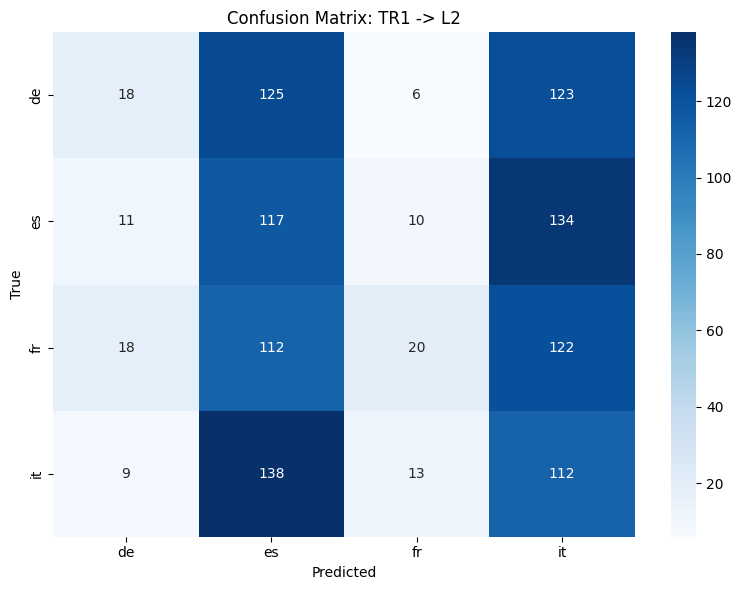

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.24540441176470587,
     de   es  fr   it
 de  18  125   6  123
 es  11  117  10  134
 fr  18  112  20  122
 it   9  138  13  112)

In [14]:
train_one_test_one(
    TR1,
    L2,
    features,
    title="TR1 -> L2"
)


===== TR1 -> TR2 =====
Test Accuracy: 0.2545955882352941

Classification Report:
               precision    recall  f1-score   support

           0     0.6667    0.0147    0.0288       272
           1     0.2461    0.9265    0.3889       272
           2     0.0000    0.0000    0.0000       272
           3     0.3684    0.0772    0.1277       272

    accuracy                         0.2546      1088
   macro avg     0.3203    0.2546    0.1363      1088
weighted avg     0.3203    0.2546    0.1363      1088


Confusion Matrix:
     de   es  fr  it
de   4  261   0   7
es   2  252   0  18
fr   0  261   0  11
it   0  250   1  21


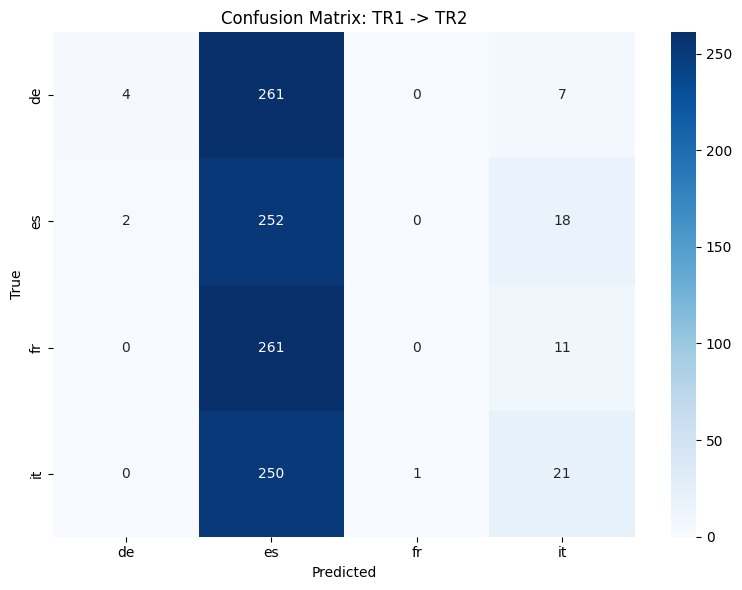

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.2545955882352941,
     de   es  fr  it
 de   4  261   0   7
 es   2  252   0  18
 fr   0  261   0  11
 it   0  250   1  21)

In [15]:
train_one_test_one(
    TR1,
    TR2,
    features,
    title="TR1 -> TR2"
)


===== TR2 -> L2 =====
Test Accuracy: 0.32628676470588236

Classification Report:
               precision    recall  f1-score   support

           0     0.3609    0.5772    0.4441       272
           1     0.2778    0.2022    0.2340       272
           2     0.3051    0.0662    0.1088       272
           3     0.3157    0.4596    0.3743       272

    accuracy                         0.3263      1088
   macro avg     0.3149    0.3263    0.2903      1088
weighted avg     0.3149    0.3263    0.2903      1088


Confusion Matrix:
      de  es  fr   it
de  157  41  13   61
es   68  55  18  131
fr  135  40  18   79
it   75  62  10  125


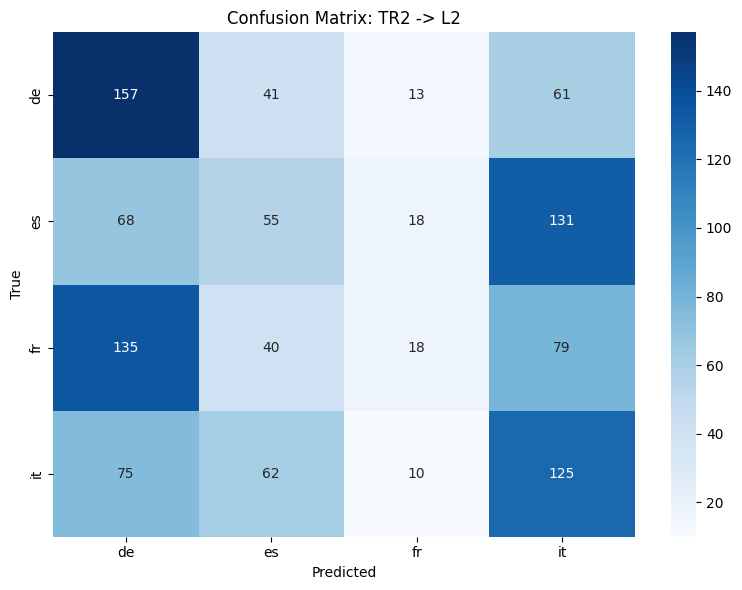

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.32628676470588236,
      de  es  fr   it
 de  157  41  13   61
 es   68  55  18  131
 fr  135  40  18   79
 it   75  62  10  125)

In [16]:
train_one_test_one(
    TR2,
    L2,
    features,
    title="TR2 -> L2"
)


===== TR2 -> TR1 =====
Test Accuracy: 0.22150735294117646

Classification Report:
               precision    recall  f1-score   support

           0     0.4545    0.1287    0.2006       272
           1     0.1968    0.2279    0.2112       272
           2     0.2607    0.2022    0.2277       272
           3     0.1835    0.3272    0.2351       272

    accuracy                         0.2215      1088
   macro avg     0.2739    0.2215    0.2187      1088
weighted avg     0.2739    0.2215    0.2187      1088


Confusion Matrix:
     de   es  fr   it
de  35  107  59   71
es   9   62  51  150
fr  14   28  55  175
it  19  118  46   89


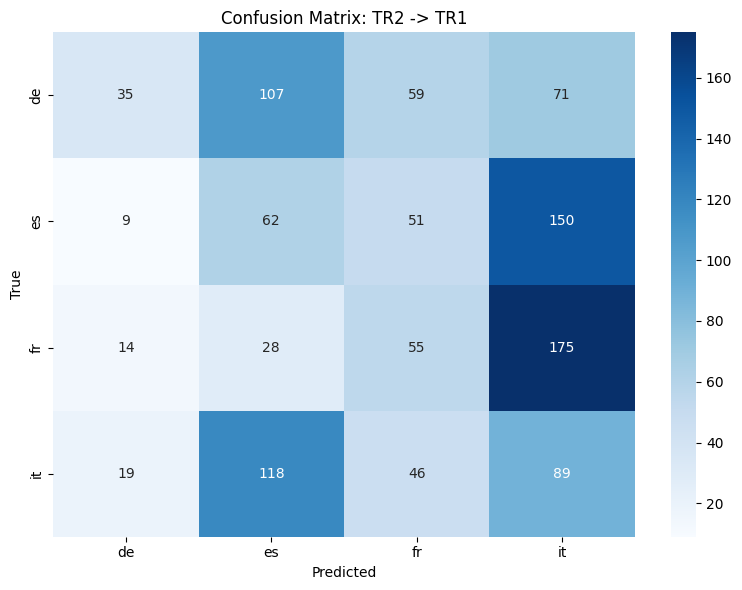

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.22150735294117646,
     de   es  fr   it
 de  35  107  59   71
 es   9   62  51  150
 fr  14   28  55  175
 it  19  118  46   89)

In [17]:
train_one_test_one(
    TR2,
    TR1,
    features,
    title="TR2 -> TR1"
)


===== L2 -> TR1 =====
Test Accuracy: 0.23805147058823528

Classification Report:
               precision    recall  f1-score   support

           0     0.2684    0.2279    0.2465       272
           1     0.0602    0.0368    0.0457       272
           2     0.2864    0.4632    0.3539       272
           3     0.2430    0.2243    0.2333       272

    accuracy                         0.2381      1088
   macro avg     0.2145    0.2381    0.2198      1088
weighted avg     0.2145    0.2381    0.2198      1088


Confusion Matrix:
     de  es   fr  it
de  62  57  117  36
es  72  10   94  96
fr  80   8  126  58
it  17  91  103  61


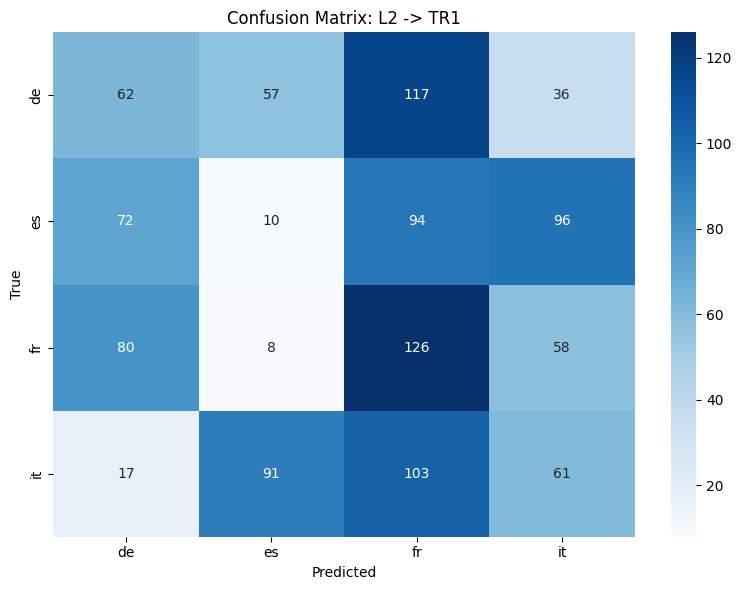

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.23805147058823528,
     de  es   fr  it
 de  62  57  117  36
 es  72  10   94  96
 fr  80   8  126  58
 it  17  91  103  61)

In [18]:
train_one_test_one(
    L2,
    TR1,
    features,
    title="L2 -> TR1"
)


===== L2 -> TR2 =====
Test Accuracy: 0.28125

Classification Report:
               precision    recall  f1-score   support

           0     0.3750    0.0221    0.0417       272
           1     0.3529    0.0221    0.0415       272
           2     0.2338    0.1728    0.1987       272
           3     0.2892    0.9081    0.4387       272

    accuracy                         0.2812      1088
   macro avg     0.3127    0.2812    0.1802      1088
weighted avg     0.3127    0.2812    0.1802      1088


Confusion Matrix:
     de  es  fr   it
de   6   5  95  166
es   2   6  43  221
fr   4   1  47  220
it   4   5  16  247


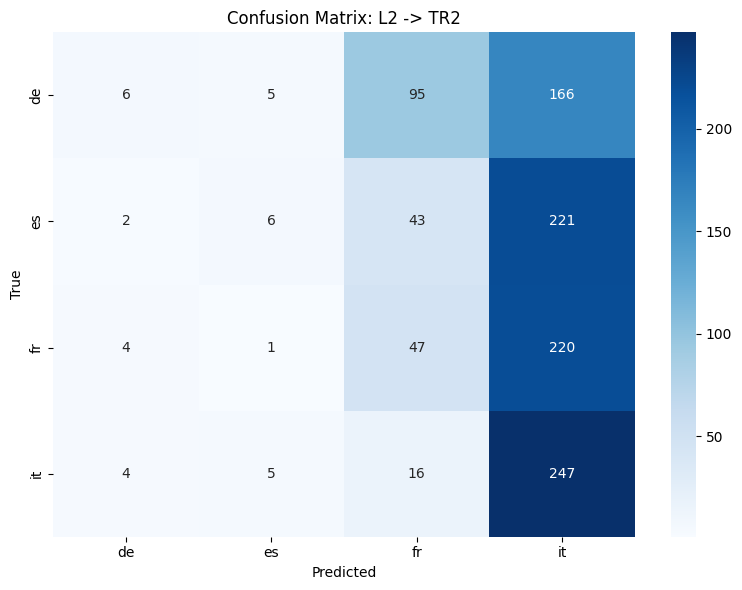

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.28125,
     de  es  fr   it
 de   6   5  95  166
 es   2   6  43  221
 fr   4   1  47  220
 it   4   5  16  247)

In [19]:
train_one_test_one(
    L2,
    TR2,
    features,
    title="L2 -> TR2"
)


===== NN -> L2 =====
Test Accuracy: 0.3014705882352941

Classification Report:
               precision    recall  f1-score   support

           0     0.3276    0.3529    0.3398       272
           1     0.0909    0.0037    0.0071       272
           2     0.2980    0.2169    0.2511       272
           3     0.2935    0.6324    0.4009       272

    accuracy                         0.3015      1088
   macro avg     0.2525    0.3015    0.2497      1088
weighted avg     0.2525    0.3015    0.2497      1088


Confusion Matrix:
     de  es  fr   it
de  96   4  53  119
es  56   1  46  169
fr  85   2  59  126
it  56   4  40  172


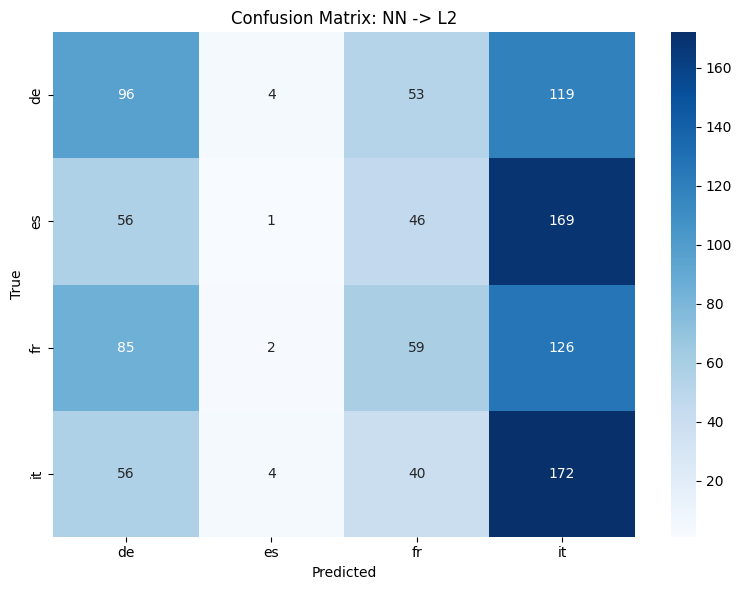

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.3014705882352941,
     de  es  fr   it
 de  96   4  53  119
 es  56   1  46  169
 fr  85   2  59  126
 it  56   4  40  172)

In [20]:
train_one_test_one(
    NN,
    L2,
    features,
    title="NN -> L2"
)


===== NN -> TR1 =====
Test Accuracy: 0.19761029411764705

Classification Report:
               precision    recall  f1-score   support

           0     0.2306    0.6434    0.3395       272
           1     0.2000    0.0037    0.0072       272
           2     0.0816    0.0882    0.0848       272
           3     0.5000    0.0551    0.0993       272

    accuracy                         0.1976      1088
   macro avg     0.2530    0.1976    0.1327      1088
weighted avg     0.2530    0.1976    0.1327      1088


Confusion Matrix:
      de  es   fr  it
de  175   2   94   1
es  247   1   17   7
fr  240   1   24   7
it   97   1  159  15


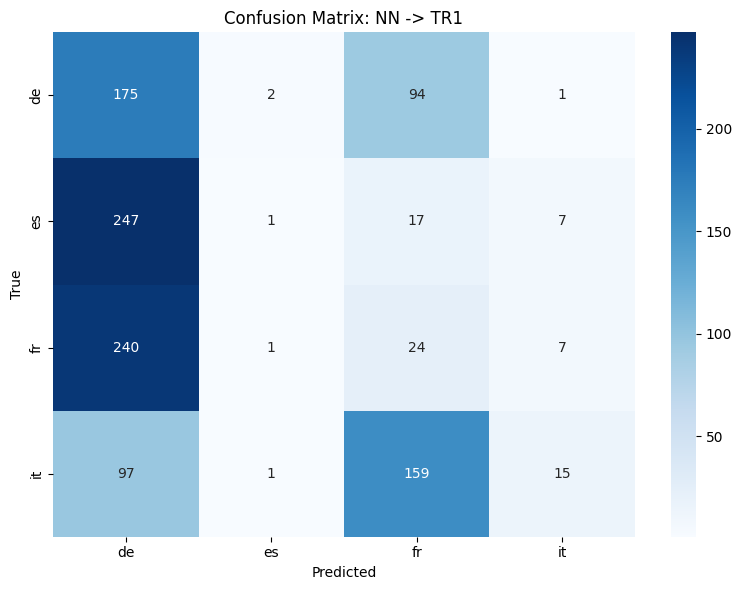

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.19761029411764705,
      de  es   fr  it
 de  175   2   94   1
 es  247   1   17   7
 fr  240   1   24   7
 it   97   1  159  15)

In [21]:
train_one_test_one(
    NN,
    TR1,
    features,
    title="NN -> TR1"
)


===== NN -> TR2 =====
Test Accuracy: 0.33455882352941174

Classification Report:
               precision    recall  f1-score   support

           0     0.3083    0.7684    0.4400       272
           1     0.0000    0.0000    0.0000       272
           2     0.1250    0.0037    0.0071       272
           3     0.3840    0.5662    0.4577       272

    accuracy                         0.3346      1088
   macro avg     0.2043    0.3346    0.2262      1088
weighted avg     0.2043    0.3346    0.2262      1088


Confusion Matrix:
      de  es  fr   it
de  209   0   1   62
es  139   0   2  131
fr  217   0   1   54
it  113   1   4  154


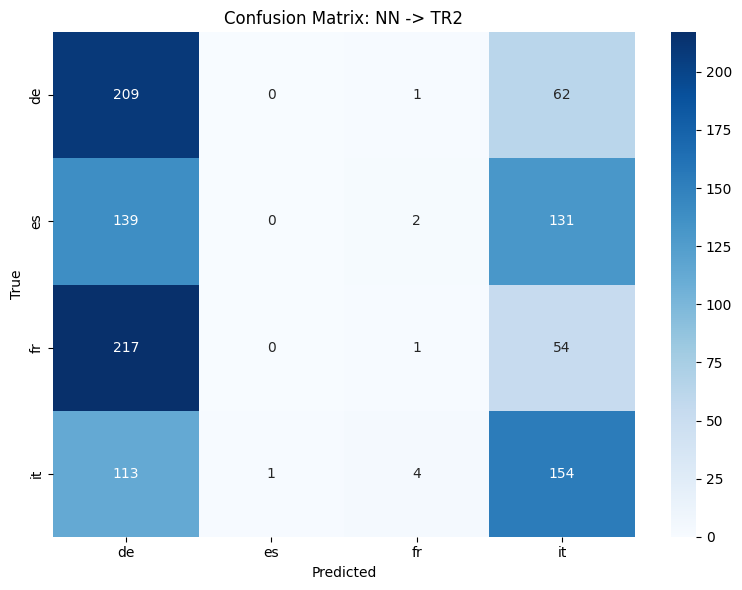

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.33455882352941174,
      de  es  fr   it
 de  209   0   1   62
 es  139   0   2  131
 fr  217   0   1   54
 it  113   1   4  154)

In [22]:
train_one_test_one(
    NN,
    TR2,
    features,
    title="NN -> TR2"
)


===== L2 -> NN =====
Test Accuracy: 0.24193548387096775

Classification Report:
               precision    recall  f1-score   support

           0     0.2500    0.0645    0.1026        31
           1     0.1579    0.0968    0.1200        31
           2     0.2807    0.5161    0.3636        31
           3     0.2250    0.2903    0.2535        31

    accuracy                         0.2419       124
   macro avg     0.2284    0.2419    0.2099       124
weighted avg     0.2284    0.2419    0.2099       124


Confusion Matrix:
     de  es  fr  it
de   2   5  13  11
es   2   3  13  13
fr   2   6  16   7
it   2   5  15   9


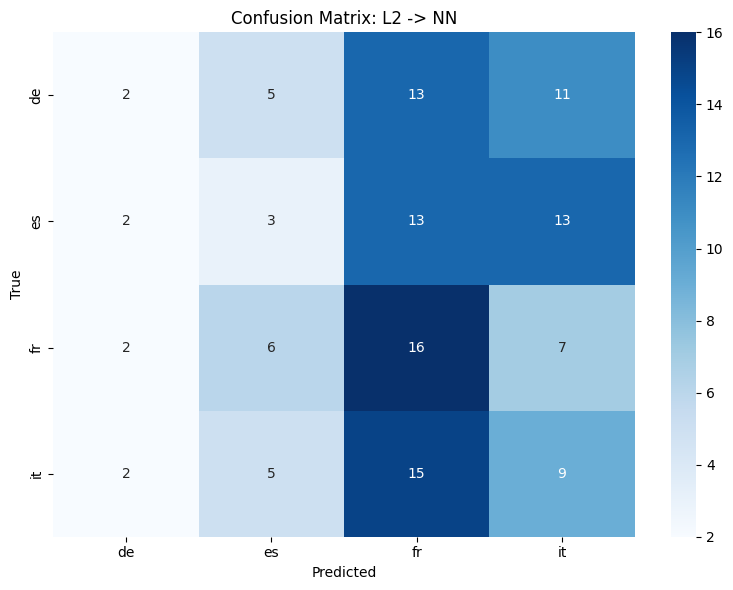

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.24193548387096775,
     de  es  fr  it
 de   2   5  13  11
 es   2   3  13  13
 fr   2   6  16   7
 it   2   5  15   9)

In [23]:
train_one_test_one(
    L2,
    NN,
    features,
    title="L2 -> NN"
)


===== TR1 -> NN =====
Test Accuracy: 0.21774193548387097

Classification Report:
               precision    recall  f1-score   support

           0     0.2222    0.0645    0.1000        31
           1     0.2558    0.3548    0.2973        31
           2     0.0000    0.0000    0.0000        31
           3     0.2258    0.4516    0.3011        31

    accuracy                         0.2177       124
   macro avg     0.1760    0.2177    0.1746       124
weighted avg     0.1760    0.2177    0.1746       124


Confusion Matrix:
     de  es  fr  it
de   2  12   4  13
es   2  11   2  16
fr   3   9   0  19
it   2  11   4  14


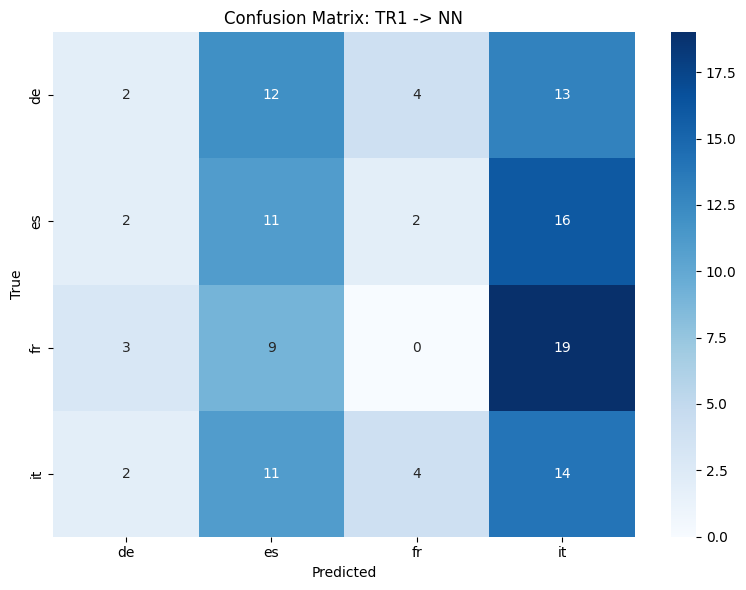

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.21774193548387097,
     de  es  fr  it
 de   2  12   4  13
 es   2  11   2  16
 fr   3   9   0  19
 it   2  11   4  14)

In [24]:
train_one_test_one(
    TR1,
    NN,
    features,
    title="TR1 -> NN"
)


===== TR2 -> NN =====
Test Accuracy: 0.22580645161290322

Classification Report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        31
           1     0.2222    0.3226    0.2632        31
           2     0.2381    0.1613    0.1923        31
           3     0.3171    0.4194    0.3611        31

    accuracy                         0.2258       124
   macro avg     0.1943    0.2258    0.2041       124
weighted avg     0.1943    0.2258    0.2041       124


Confusion Matrix:
     de  es  fr  it
de   0  12   8  11
es   3  10   6  12
fr   7  14   5   5
it   7   9   2  13


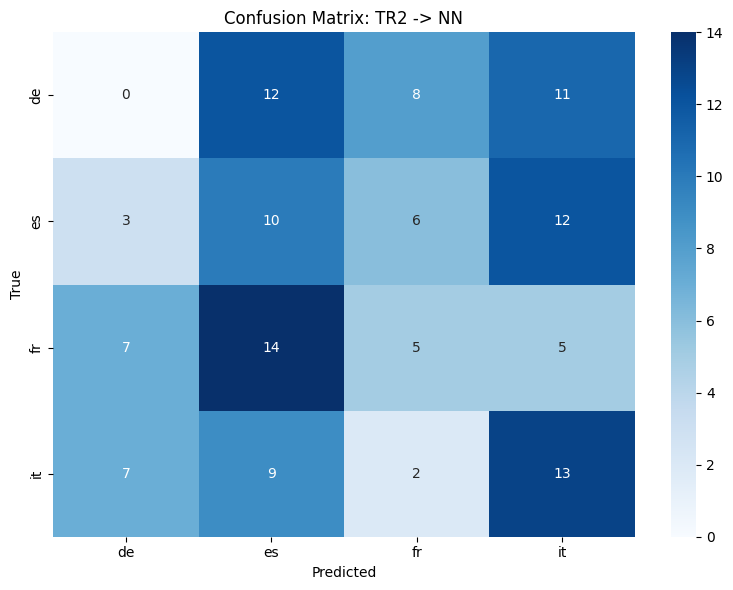

(MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32), random_state=42),
 0.22580645161290322,
     de  es  fr  it
 de   0  12   8  11
 es   3  10   6  12
 fr   7  14   5   5
 it   7   9   2  13)

In [25]:
train_one_test_one(
    TR2,
    NN,
    features,
    title="TR2 -> NN"
)

# RQ4: Which variation dimension play a greater role – L1 or production type?

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def run_kmeans_evaluation(df, n_clusters=None, label_col='L1', drop_cols=None, plot=True):

    #df = df.dropna().copy()

    # Separate labels
    y_true = df[label_col].values

    # Drop non-feature columns
    if drop_cols is not None:
        df_features = df.drop(drop_cols, axis=1)
    else:
        df_features = df.drop(columns=[label_col])

    X = df_features.values

    # SCALE FEATURES
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Auto-set clusters = number of classes if not given
    if n_clusters is None:
        n_clusters = len(np.unique(y_true))

    # Fit KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_ids = kmeans.fit_predict(X)

    df['cluster'] = cluster_ids

    cluster_to_label = {}

    for cluster in np.unique(cluster_ids):
        mask = (cluster_ids == cluster)

        if np.sum(mask) == 0:
            continue

        unique_labels, counts = np.unique(y_true[mask], return_counts=True)

        # Assign most frequent label
        cluster_to_label[cluster] = unique_labels[np.argmax(counts)]

    # Map predictions
    y_pred = np.array([cluster_to_label[c] for c in cluster_ids])

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print("Clustering Accuracy:", accuracy)
    labels = sorted(set(y_true) | set(y_pred))

    confusion_matrix = pd.crosstab(
        y_true,
        y_pred,
        rownames=['True'],
        colnames=['Pred']
    ).reindex(index=labels, columns=labels, fill_value=0)
    print(confusion_matrix)

    print("\nClassification Report:\n",
          classification_report(y_true, y_pred, digits=4, zero_division=0))

    # Plot
    if plot:
        plt.figure(figsize=(8,6))
        sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
        plt.title(f'KMeans Confusion Matrix (k={n_clusters})')
        plt.show()

    df = df.drop('cluster', axis=1)

    return df, accuracy, confusion_matrix

In [27]:
def leave_one_language_out_kmeans(df, label_col='L1', drop_cols=None, plot=False):

    results = {}
    languages = df[label_col].unique()

    for lang in languages:
        print("\n" + "="*50)
        print(f"Removing language: {lang}")
        print("="*50)

        # Filter out one language
        df_subset = df[df[label_col] != lang].copy()

        # Run KMeans on remaining languages
        _, acc, cm = run_kmeans_evaluation(
            df_subset,
            n_clusters=len(languages) - 1,
            label_col=label_col,
            drop_cols=drop_cols,
            plot=plot
        )

        # Store results
        results[lang] = {
            "accuracy": acc,
            "confusion_matrix": cm
        }

    return results



Removing language: de
Clustering Accuracy: 0.375836284927194
Pred   es  fr   it
True              
es    289   0  558
fr    272   0  575
it    181   0  666

Classification Report:
               precision    recall  f1-score   support

          es     0.3895    0.3412    0.3638       847
          fr     0.0000    0.0000    0.0000       847
          it     0.3702    0.7863    0.5034       847

    accuracy                         0.3758      2541
   macro avg     0.2532    0.3758    0.2891      2541
weighted avg     0.2532    0.3758    0.2891      2541



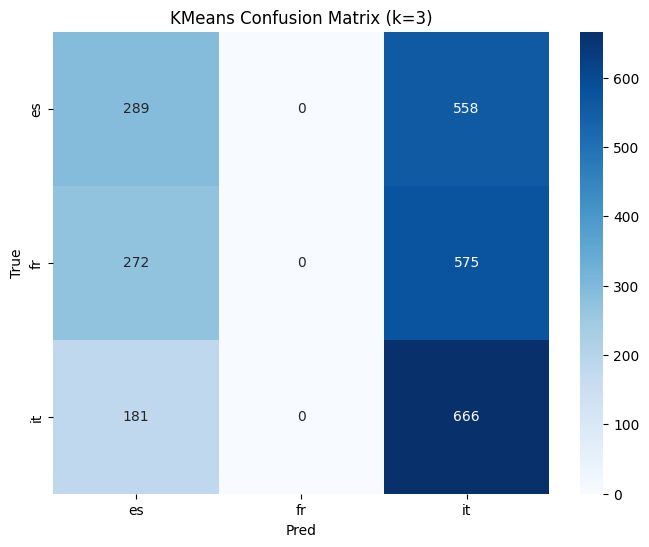


Removing language: es
Clustering Accuracy: 0.3730814639905549
Pred  de   fr   it
True              
de     0  227  620
fr     0  269  578
it     0  168  679

Classification Report:
               precision    recall  f1-score   support

          de     0.0000    0.0000    0.0000       847
          fr     0.4051    0.3176    0.3561       847
          it     0.3617    0.8017    0.4985       847

    accuracy                         0.3731      2541
   macro avg     0.2556    0.3731    0.2849      2541
weighted avg     0.2556    0.3731    0.2849      2541



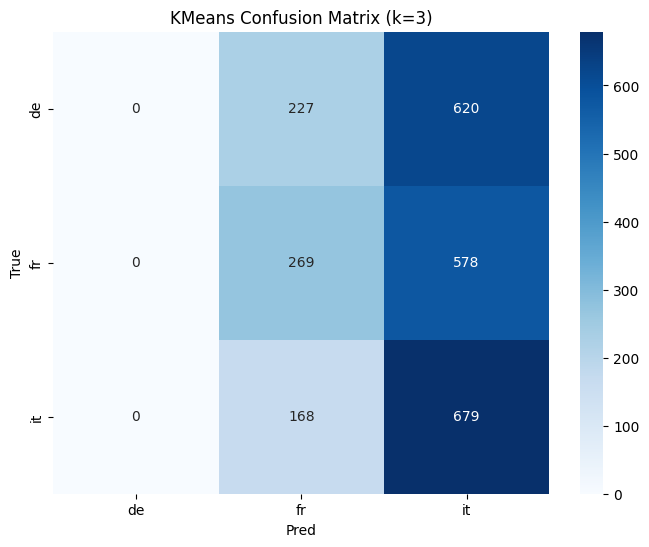


Removing language: fr
Clustering Accuracy: 0.37662337662337664
Pred  de   es   it
True              
de     0  229  618
es     0  289  558
it     0  179  668

Classification Report:
               precision    recall  f1-score   support

          de     0.0000    0.0000    0.0000       847
          es     0.4146    0.3412    0.3744       847
          it     0.3623    0.7887    0.4965       847

    accuracy                         0.3766      2541
   macro avg     0.2590    0.3766    0.2903      2541
weighted avg     0.2590    0.3766    0.2903      2541



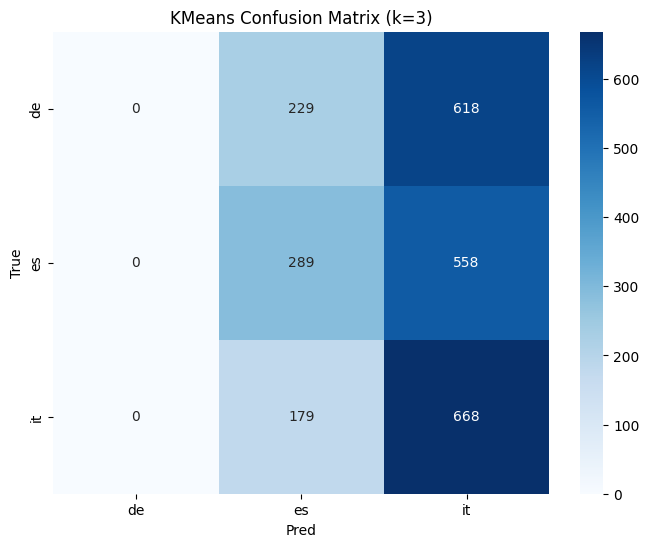


Removing language: it
Clustering Accuracy: 0.358913813459268
Pred  de   es   fr
True              
de    53  228  566
es     0  286  561
fr     4  270  573

Classification Report:
               precision    recall  f1-score   support

          de     0.9298    0.0626    0.1173       847
          es     0.3648    0.3377    0.3507       847
          fr     0.3371    0.6765    0.4499       847

    accuracy                         0.3589      2541
   macro avg     0.5439    0.3589    0.3060      2541
weighted avg     0.5439    0.3589    0.3060      2541



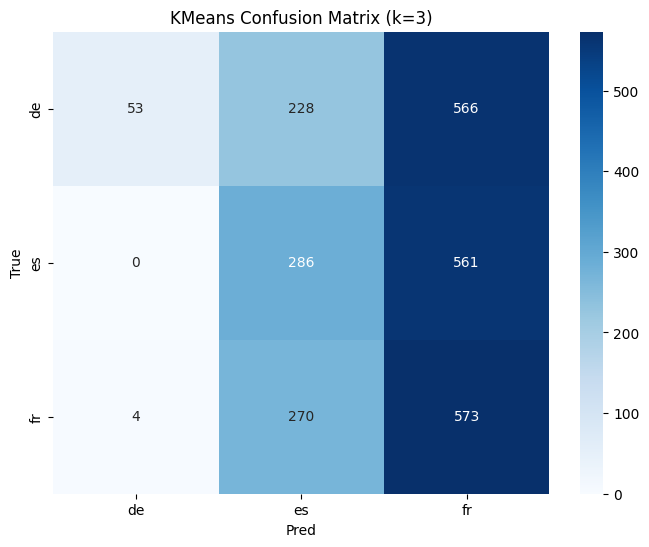

In [28]:
results = leave_one_language_out_kmeans(
df,
label_col='L1',
drop_cols=['L1',"dataset_name"],
plot=True
)


Removing language: de
Clustering Accuracy: 0.885478158205431
Pred   L2  NN  TR1  TR2
True                   
L2    700   0    4  112
NN     28   0   16   49
TR1     7   0  748   61
TR2    11   0    3  802

Classification Report:
               precision    recall  f1-score   support

          L2     0.9383    0.8578    0.8963       816
          NN     0.0000    0.0000    0.0000        93
         TR1     0.9702    0.9167    0.9427       816
         TR2     0.7832    0.9828    0.8717       816

    accuracy                         0.8855      2541
   macro avg     0.6729    0.6893    0.6777      2541
weighted avg     0.8644    0.8855    0.8705      2541



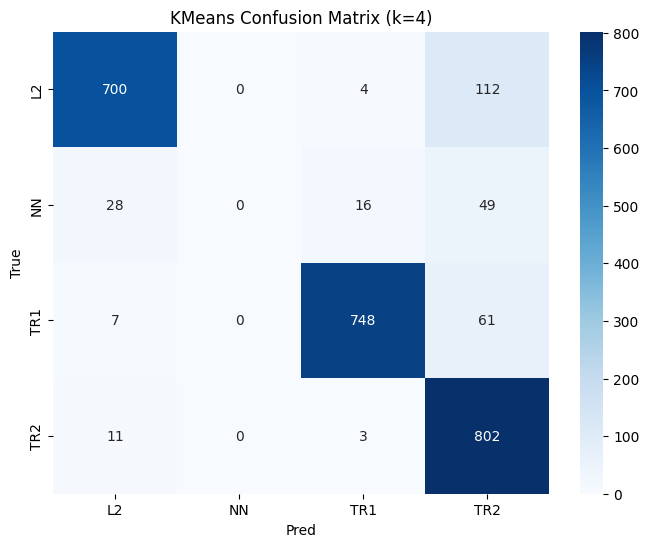


Removing language: es
Clustering Accuracy: 0.8780007870916962
Pred   L2  NN  TR1  TR2
True                   
L2    678   0    3  135
NN     26   0   22   45
TR1    10   0  749   57
TR2    11   0    1  804

Classification Report:
               precision    recall  f1-score   support

          L2     0.9352    0.8309    0.8799       816
          NN     0.0000    0.0000    0.0000        93
         TR1     0.9665    0.9179    0.9415       816
         TR2     0.7723    0.9853    0.8659       816

    accuracy                         0.8780      2541
   macro avg     0.6685    0.6835    0.6719      2541
weighted avg     0.8587    0.8780    0.8630      2541



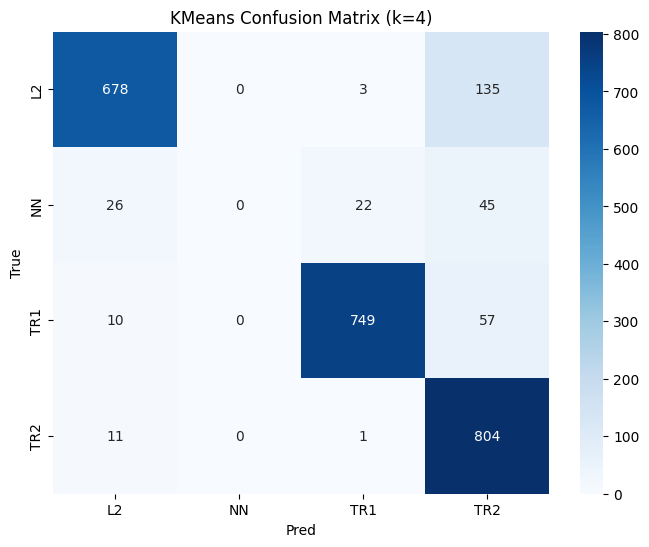


Removing language: fr
Clustering Accuracy: 0.8728846910665092
Pred   L2  NN  TR1  TR2
True                   
L2    658   0    2  156
NN     19   0   21   53
TR1     4   0  754   58
TR2     8   0    2  806

Classification Report:
               precision    recall  f1-score   support

          L2     0.9550    0.8064    0.8744       816
          NN     0.0000    0.0000    0.0000        93
         TR1     0.9679    0.9240    0.9455       816
         TR2     0.7512    0.9877    0.8534       816

    accuracy                         0.8729      2541
   macro avg     0.6685    0.6795    0.6683      2541
weighted avg     0.8587    0.8729    0.8585      2541



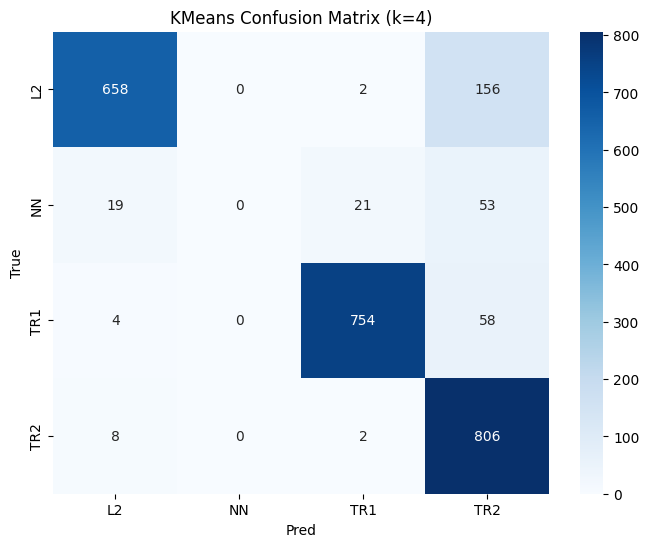


Removing language: it
Clustering Accuracy: 0.8728846910665092
Pred   L2  NN  TR1  TR2
True                   
L2    634   0    0  182
NN     16   0   25   52
TR1     2   0  773   41
TR2     4   0    1  811

Classification Report:
               precision    recall  f1-score   support

          L2     0.9665    0.7770    0.8614       816
          NN     0.0000    0.0000    0.0000        93
         TR1     0.9675    0.9473    0.9573       816
         TR2     0.7468    0.9939    0.8528       816

    accuracy                         0.8729      2541
   macro avg     0.6702    0.6795    0.6679      2541
weighted avg     0.8609    0.8729    0.8579      2541



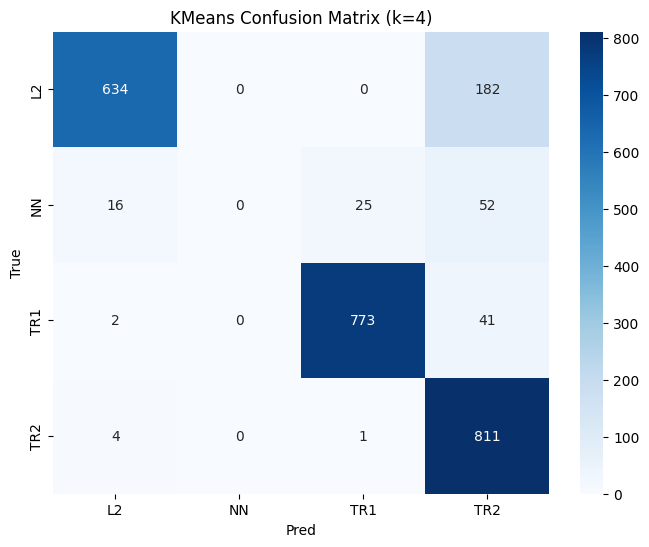

In [29]:
def leave_one_language_out_kmeans_dataset(df, label_col='L1', drop_cols=None, plot=False):

    results = {}
    languages = df[label_col].unique()

    for lang in languages:
        print("\n" + "="*50)
        print(f"Removing language: {lang}")
        print("="*50)

        # Filter out one language
        df_subset = df[df[label_col] != lang].copy()

        # Run KMeans on remaining languages
        _, acc, cm = run_kmeans_evaluation(
            df_subset,
            n_clusters = df_subset['dataset_name'].nunique(),
            label_col='dataset_name',
            drop_cols=drop_cols,
            plot=plot
        )

        # Store results
        results[lang] = {
            "accuracy": acc,
            "confusion_matrix": cm
        }

    return results


results = leave_one_language_out_kmeans_dataset(
df,
label_col='L1',
drop_cols=['L1',"dataset_name"],
plot=True
)

#RQ5: Which linguistic features contribute most to L1 identification and if they differ from those differentiating language products, i.e. general language variation indicators

In [30]:
num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]

print("Numeric feature columns:", numerical_cols)

Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']


In [31]:

l1_values = ["es", "de", "fr", "it"]
df_filtered = df[df["L1"].isin(l1_values)]

# Count of L1 per L2
count_per_L2 = df_filtered.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0)

print(count_per_L2)


L1             de   es   fr   it
dataset_name                    
L2            272  272  272  272
NN             31   31   31   31
TR1           272  272  272  272
TR2           272  272  272  272


In [32]:
df_balanced = df
to_drop = [c for c in ['L1','dataset_name','cluster','kmeans_labels'] if c in df_balanced.columns]
feature_cols = [c for c in df_balanced.columns if c not in to_drop]

df_balanced = df_balanced.dropna()
X_s = df_balanced[feature_cols].values
y_balanced = df_balanced['L1'].values  # target: L1

In [33]:

 # Required packages
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import os
#selectbest
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_s, y_balanced)
top_idx = selector.get_support(indices=True)
top10_SelectKBEST = [feature_cols[i] for i in top_idx]

print("Top 10 features by ANOVA F-test:", top10_SelectKBEST)

os.makedirs("/content/plots_SelectKBest", exist_ok=True)

# create the 8-class column correctly
df_plot = df_balanced.copy()
df_plot['class'] = df_plot['dataset_name'].astype(str) + "_" + df_plot['L1'].astype(str)  # e.g. "L2_es"

# classes in correct order
classes = ["L2_es","L2_de","L2_fr","L2_it","TR1_es","TR1_de","TR1_fr","TR1_it","TR2_es","TR2_de","TR2_fr","TR2_it","NN_es","NN_de","NN_fr","NN_it"]


# coerce features to numeric safely
for f in top10_SelectKBEST:
    df_plot[f] = pd.to_numeric(df_plot[f], errors='coerce')

# create plots and save individually
for feat in top10_SelectKBEST:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='class', y=feat, data=df_plot, order=classes)
    plt.title(feat)
    plt.xlabel("")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # save each feature individually
    plt.savefig(f"/content/plots_SelectKBest/{feat}.png", dpi=300)
    plt.close()   # important to avoid overlap


for feat in top10_SelectKBEST:
    plt.figure(figsize=(8,4))

    # KDE plot for all classes overlaid
    for cls in classes:
        subset = df_plot[df_plot['class'] == cls]
        if not subset.empty:
            sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4)

    plt.title(f"KDE of {feat} by class")
    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()

    # save individually
    plt.savefig(f"/content/plots_SelectKBest/{feat}_KDE.png", dpi=300)
    plt.close()


Top 10 features by ANOVA F-test: ['cconj', 'relativ', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'numcls', 'simple', 'nnargs', 'mhd']


/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


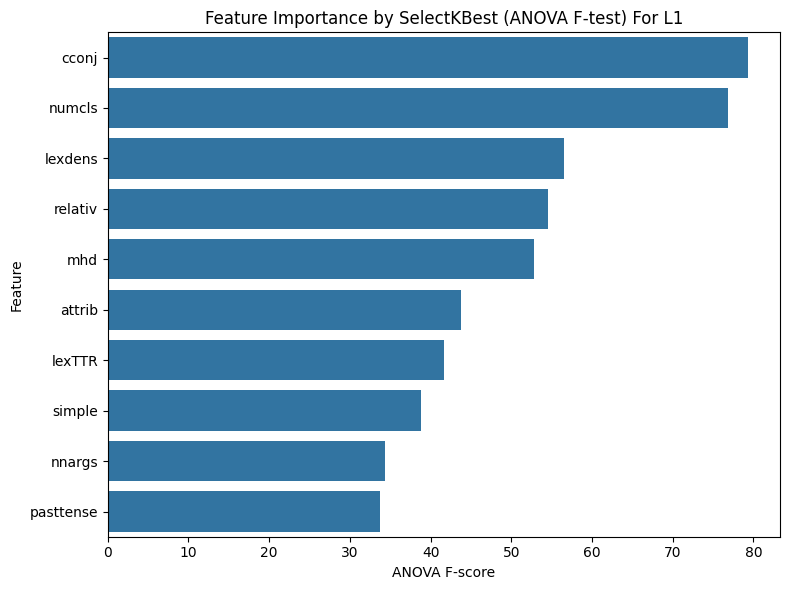

In [34]:
# Get the F-scores and p-values
f_scores = selector.scores_[top_idx]
p_values = selector.pvalues_[top_idx]

# Sort descending for horizontal bar plot
importance_df = pd.DataFrame({
    'Feature': top10_SelectKBEST,
    'F_score': f_scores,
    'p_value': p_values
}).sort_values(by='F_score', ascending=False)  # now highest F-score on top

# Plot horizontal bar plot
plt.figure(figsize=(8,6))
sns.barplot(x='F_score', y='Feature', data=importance_df)
plt.xlabel("ANOVA F-score")
plt.ylabel("Feature")
plt.title("Feature Importance by SelectKBest (ANOVA F-test) For L1")
plt.tight_layout()
plt.savefig("./plots_SelectKBest/Top10_Feature_Importance_desc.png", dpi=300)
plt.show()

In [35]:
!zip -r plots_SelectKBest.zip plots_SelectKBest

  adding: plots_SelectKBest/ (stored 0%)
  adding: plots_SelectKBest/mhd_KDE.png (deflated 9%)
  adding: plots_SelectKBest/numcls.png (deflated 19%)
  adding: plots_SelectKBest/lexdens.png (deflated 19%)
  adding: plots_SelectKBest/pasttense.png (deflated 18%)
  adding: plots_SelectKBest/lexdens_KDE.png (deflated 9%)
  adding: plots_SelectKBest/simple_KDE.png (deflated 7%)
  adding: plots_SelectKBest/simple.png (deflated 20%)
  adding: plots_SelectKBest/pasttense_KDE.png (deflated 8%)
  adding: plots_SelectKBest/relativ_KDE.png (deflated 10%)
  adding: plots_SelectKBest/cconj.png (deflated 19%)
  adding: plots_SelectKBest/nnargs_KDE.png (deflated 8%)
  adding: plots_SelectKBest/attrib_KDE.png (deflated 9%)
  adding: plots_SelectKBest/cconj_KDE.png (deflated 10%)
  adding: plots_SelectKBest/relativ.png (deflated 18%)
  adding: plots_SelectKBest/mhd.png (deflated 19%)
  adding: plots_SelectKBest/numcls_KDE.png (deflated 11%)
  adding: plots_SelectKBest/nnargs.png (deflated 19%)
  adding: